# EDA and Modeling

## Step 1. Imports

*   Import packages
*   Load dataset

In [2]:
# For data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# For data modeling
import catboost
from catboost import CatBoostRegressor, Pool

## For metrics and helpful functions
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from collections import Counter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 


In [3]:
# Load the data into DF
df = pd.read_csv('completed_file.csv')

In [4]:
# Display few rows of the data
df.head()

,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description
0,2024-06-23,Data Scientist,"Dese Research, Inc.",Alabama,Huntsville,Mid-level,NaN,NaN,NaN,NaN,"Familiarity with advanced machine learning, da..."
1,2024-06-23,Senior Data Analyst,Pci Government Services,Alabama,Huntsville,Senior,NaN,85000.0,year,NaN,Must have strong technical skills in areas suc...
2,2024-06-23,Data Scientist,"Interclypse, Inc.",Alabama,Huntsville,Mid-level,NaN,NaN,NaN,Full-time,Excellent interpersonal skills and ability to ...
3,2024-06-23,"Data Scientist, Mid",Booz Allen,Alabama,Huntsville,Mid-level,NaN,123800.0,year,NaN,"As a data scientist, you’re excited at the pro..."
4,2024-06-23,Senior Data Analyst (u.s. Remote Eligible),"Eternal Word Television Network, Inc.",Alabama,Alabama,Senior,Remote,NaN,NaN,NaN,You are experienced using web analytics and Go...


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers) 

In [5]:
# Display a basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             29184 non-null  object 
 1   Title            29184 non-null  object 
 2   Company          29184 non-null  object 
 3   State            29184 non-null  object 
 4   City             29182 non-null  object 
 5   Level            29184 non-null  object 
 6   Work Mode        1177 non-null   object 
 7   Average Salary   11377 non-null  float64
 8   Pay Type         11437 non-null  object 
 9   Employment Type  4905 non-null   object 
 10  Description      22755 non-null  object 
dtypes: float64(1), object(10)
memory usage: 2.4+ MB


In [6]:
# Descriptive summary
df.describe(include = 'all')

,Date,Title,Company,State,City,Level,Work Mode,Average Salary,Pay Type,Employment Type,Description
count,29184,29184,29184,29184,29182,29184,1177,1.137700e+04,11437,4905,22755
unique,36,8124,4078,52,1043,8,3,NaN,5,27,12956
top,2024-06-23,Data Scientist,Amazon.com Services Llc,California,Remote,Mid-level,Remote,NaN,year,Full-time,"Note: Apple benefit, compensation and employee..."
freq,4745,1429,948,5400,1962,17556,761,NaN,10741,4560,139
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.536191e+05,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.324753e+04,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238000e+05,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.563025e+05,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.906580e+05,NaN,NaN,NaN


**Correct data type**

In [7]:
# Convert Data column into Data Time data type
df['Date'] = pd.to_datetime(df['Date'])

**Check duplicated and missing data**

In [8]:
# The total number of duplicated and missing data
print(df.duplicated().sum()) # check duplicated rows
print(df.isna().sum()) # check missing rows

16
Date                   0
Title                  0
Company                0
State                  0
City                   2
Level                  0
Work Mode          28007
Average Salary     17807
Pay Type           17747
Employment Type    24279
Description         6429
dtype: int64


In [9]:
# Remove duplicated data
df = df.drop_duplicates()

- Handling missing data

In [10]:
# The percentage of missing data
missing_percent = (df.isna().mean() * 100).round(3)
print(missing_percent)

Date                0.000
Title               0.000
Company             0.000
State               0.000
City                0.007
Level               0.000
Work Mode          95.972
Average Salary     61.015
Pay Type           60.810
Employment Type    83.197
Description        22.024
dtype: float64


`Employement Types`

In [11]:
df['Employment Type'].value_counts()

Employment Type
Full-time                 4556
Contract                   120
Full-time\n+1               52
Part-time                   43
Monday to Friday            24
Day Shift                   17
Temporary                   12
Permanent                    9
Flextime                     8
On call                      8
Internship                   7
Weekends as needed\n+1       7
Seasonal                     6
Tenure track                 5
Internship\n+1               4
Weekends as needed\n+2       4
Weekends as needed           4
Overtime                     4
Monday to Friday\n+2         2
PRN                          2
Non-tenure                   1
Holidays                     1
Temp-to-hire                 1
Part-time\n+1                1
Per diem                     1
Full-time\n+2                1
Weekends as needed\n+3       1
Name: count, dtype: int64

In [12]:
# define a function to harmonize the data in the `employement type` column

def harmonize_employment_type(x):
    if pd.isna(x):  # check for NaN
        return np.nan
    x = str(x)
    if 'Full-time' in x:
        return 'Full-time'
    elif 'Permanent' in x:
        return 'Full-time'
    elif 'Part-time' in x:
        return 'Part-time'
    elif 'Internship' in x:
        return 'Internship'
    else:
        return 'Casual'

df['Employment Type'] = df['Employment Type'].apply(harmonize_employment_type)


In [13]:
# apply the function
df['Employment Type'].value_counts()

Employment Type
Full-time     4618
Casual         228
Part-time       44
Internship      11
Name: count, dtype: int64

Missing values in the `employment type` column **will be filled** from `Pay type` column, using this rule: **hour/day/week → Casual**, **month → Part-time**, **year → Full-time**.



In [14]:
df.loc[df['Pay Type'] == 'year', 'Employment Type'] = df.loc[df['Pay Type'] == 'year', 'Employment Type'].fillna('Full-time')
df.loc[df['Pay Type'] == 'month', 'Employment Type'] = df.loc[df['Pay Type'] == 'month', 'Employment Type'].fillna('Part-time')
df.loc[df['Pay Type'].isin(['hour', 'day', 'week']), 'Employment Type'] = df.loc[df['Pay Type'].isin(['hour', 'day', 'week']), 'Employment Type'].fillna('Casual')

In [15]:
print(df['Employment Type'].value_counts())
print(df['Employment Type'].isna().sum())

Employment Type
Full-time     15353
Casual          807
Part-time       101
Internship       11
Name: count, dtype: int64
12896


The remaining missing values with the most frequent values

In [16]:
mode = df['Employment Type'].mode()[0]
df['Employment Type'] = df['Employment Type'].fillna(mode)

Now map the missing data in `pay type` column with the data in `employment type` column

In [17]:
print(df['Employment Type'].unique())
print(df['Pay Type'].unique())

['Full-time' 'Casual' 'Part-time' 'Internship']
[nan 'year' 'day' 'hour' 'month' 'week']


In [18]:
df['Pay Type'] = df['Pay Type'].fillna(
    df['Employment Type'].map({
        'Full-time': 'year',
        'Casual': 'hour',
        'Part-time': 'month',
        'Internship': 'NA' # for internship type, map as 'NA'
    })
)

`Description`

In [19]:
#Fill missing data with 'NA' 
df['Description'] = df['Description'].fillna('NA')

`City`

In [20]:
df[['Company','State','City']][df['City'].isna()]

,Company,State,City
12827,Enterprise Knowledge (ek),District of Columbia,NaN
12993,Vast Data,Massachusetts,NaN


These companies have not specified their city location, and their addresses are not available online. Therefore, the `City` will be set as `NA`.

In [21]:
# map the missing data with 'NA' values
df['City'] = df['City'].fillna('NA')

`Work Mode`

In [22]:
# check the percentage of missing data in work mode column
print('Missing %:', df['Work Mode'].isna().mean() * 100)
print('Count not missing data:', df['Work Mode'].value_counts())

Missing %: 95.97161272627537
Count not missing data: Work Mode
Remote     759
Hybrid     361
On-site     55
Name: count, dtype: int64


Given that approximately 97% of the entries in this column are missing, the column lacks sufficient information and will be excluded from further analysis.

In [23]:
df = df.drop(columns='Work Mode', axis = 1)

`Average Salary`

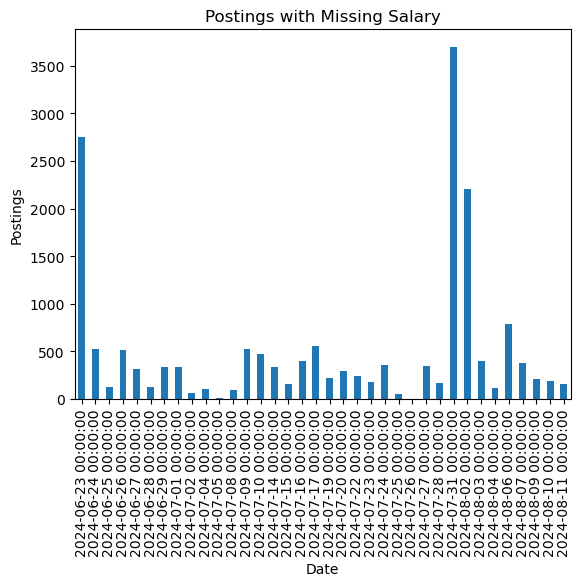

In [24]:
# Plot the missing values in the `Average Salary` column

df.groupby('Date')['Average Salary'].apply(lambda x: x.isna().sum() ).plot(kind='bar')
plt.ylabel('Postings')
plt.title('Postings with Missing Salary')
plt.show()

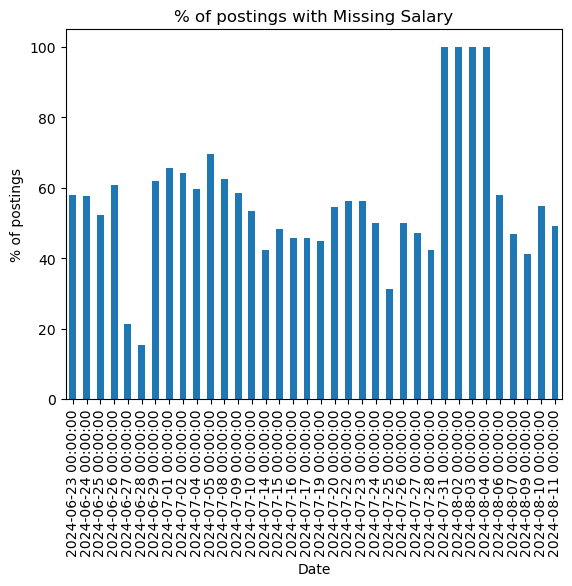

In [25]:
# Plot the missing values in the `Average Salary` column

df.groupby('Date')['Average Salary'].apply(lambda x: x.isna().sum() / len(x) * 100).plot(kind='bar')
plt.ylabel('% of postings')
plt.title('% of postings with Missing Salary')
plt.show()

Around 61% missing data in `Average Salary` column,  we will use model to predict the average salary based on relevant features after the EDA.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

`Date`

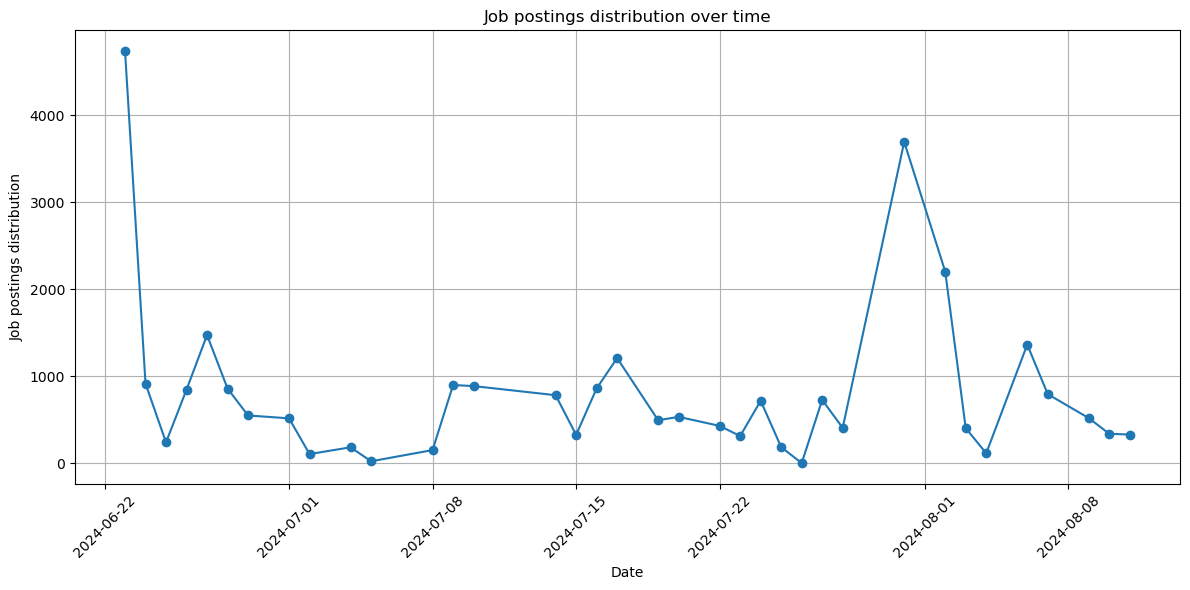

In [26]:
job_postings_count = df.groupby('Date').size()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(job_postings_count.index, job_postings_count.values, marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Job postings distribution')
plt.title('Job postings distribution over time')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.grid(True) 

Create a `Weekday` column to visualzie the week day posting trend

In [27]:
# Generate new columns weekday 

df['Weekday'] = df['Date'].dt.day_name()

In [28]:
# Define weekday order

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Count total job posts per weekday
posts_per_weekday = df.groupby('Weekday').size()

# Count number of unique dates each weekday appears
weekday_dates = df.groupby('Weekday')['Date'].nunique()

# Average posts per weekday occurrence
avg_posts_per_weekday = round(posts_per_weekday / weekday_dates)

# Convert index to Categorical to enforce weekday order
avg_posts_per_weekday = avg_posts_per_weekday.reindex(weekday_order)

print(avg_posts_per_weekday)


Weekday
Monday        468.0
Tuesday       631.0
Wednesday    1359.0
Thursday      615.0
Friday        684.0
Saturday      511.0
Sunday       1276.0
dtype: float64


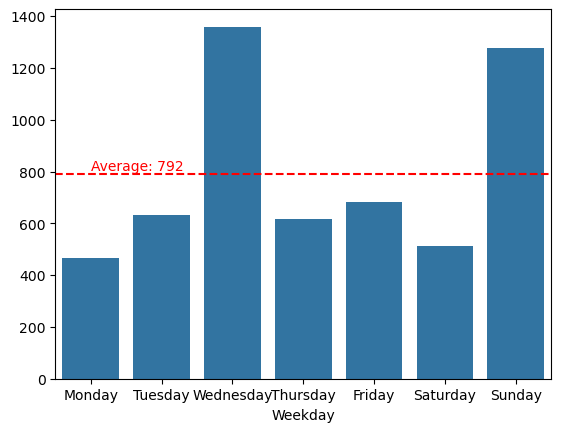

In [29]:
# plot the average job postings by weekday
sns.barplot(x=avg_posts_per_weekday.index, y=avg_posts_per_weekday.values)
overall_avg = avg_posts_per_weekday.mean()
plt.axhline(overall_avg, color='red', linestyle='--')
plt.text(0, 805, f"Average: {overall_avg:.0f}", color='red')
plt.show()

The data shows an average of 792 job postings per day. Midweek (Wednesday) sees the peak posting activity, followed by Sunday, suggesting that employers may prioritize posting at the start and middle of the week. Other days have relatively stable posting numbers between 460 and 700.

`State`, `City`, `Company`, `Title`

In [30]:
print('Number of State: ', df['State'].nunique())
print('Number of City: ', df['City'].nunique())
print('Number of Company: ', df['Company'].nunique())
print('Number of Title: ', df['Title'].nunique())

Number of State:  52
Number of City:  1044
Number of Company:  4078
Number of Title:  8124


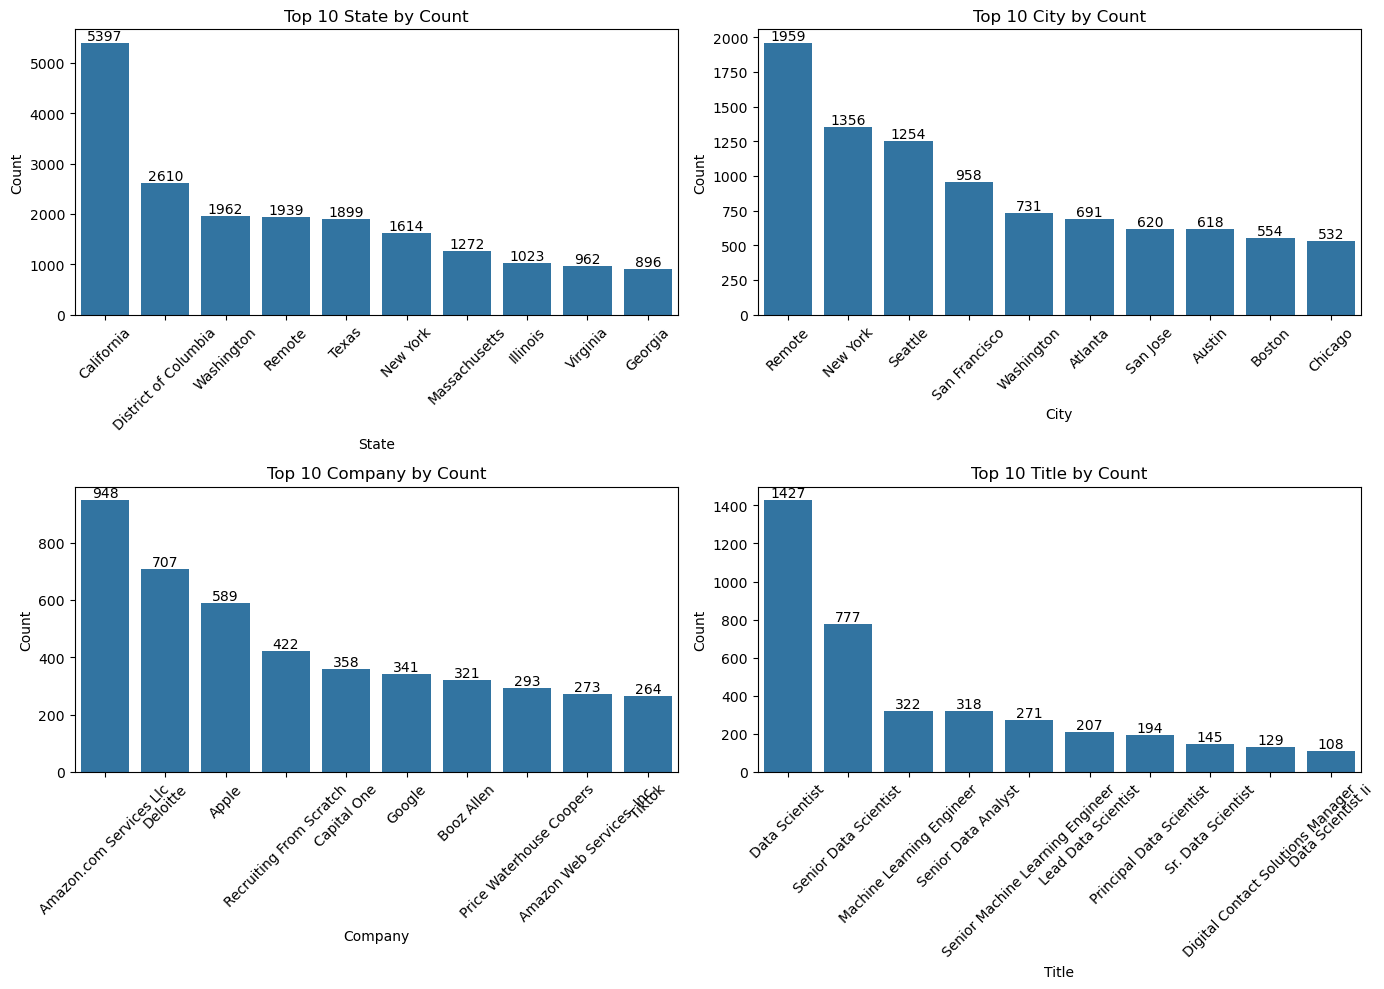

In [31]:
# Plot top 10 states, city, company, title by number of postings

cols = ['State', 'City', 'Company', 'Title']
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    top10 = df[col].value_counts().head(10)
    row = i // 2
    col_idx = i % 2

    sns.countplot(x=col, data=df, order=top10.index, ax=ax[row, col_idx])
    
    ax[row, col_idx].set_title(f'Top 10 {col} by Count')
    ax[row, col_idx].set_ylabel('Count')
    ax[row, col_idx].tick_params(axis='x', rotation=45)
    ax[row, col_idx].bar_label(ax[row, col_idx].containers[0])

plt.tight_layout()
plt.show()


- California leads the nation in data-science recruiting, which is expected given the concentration of major tech companies in the state. Its 5,397 job postings are almost twice the number of the second-highest state, clearly illustrating the intense demand for data-science talent. Within California, San Francisco and San Jose stand out as the top contributing cities.

- Remote roles dominate a large portion of the listings, suggesting that many employers continue to embrace flexible work arrangements and do not require employees to be physically present in an office.

`Employment type`

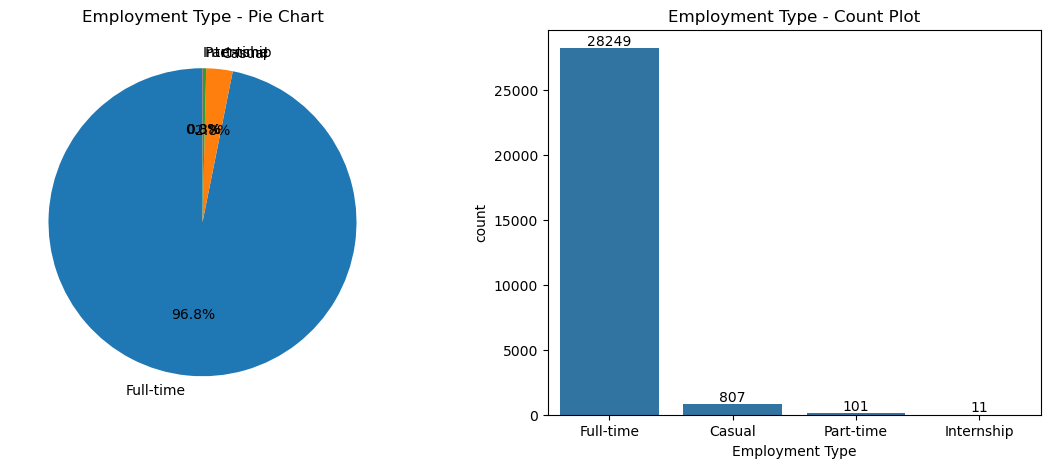

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['Employment Type'].value_counts()
ax[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
ax[0].set_title("Employment Type - Pie Chart")

# Countplot 
sns.countplot(data=df, x='Employment Type', ax=ax[1])
ax[1].set_title("Employment Type - Count Plot")
ax[1].bar_label(ax[1].containers[0])
plt.show()


- Full-time roles dominate the data science field (96,8%), indicating that employers prefer permanent, long-term employees for these positions. As a result, opportunities for part-time, casual, or internship roles are relatively limited.

`Title`

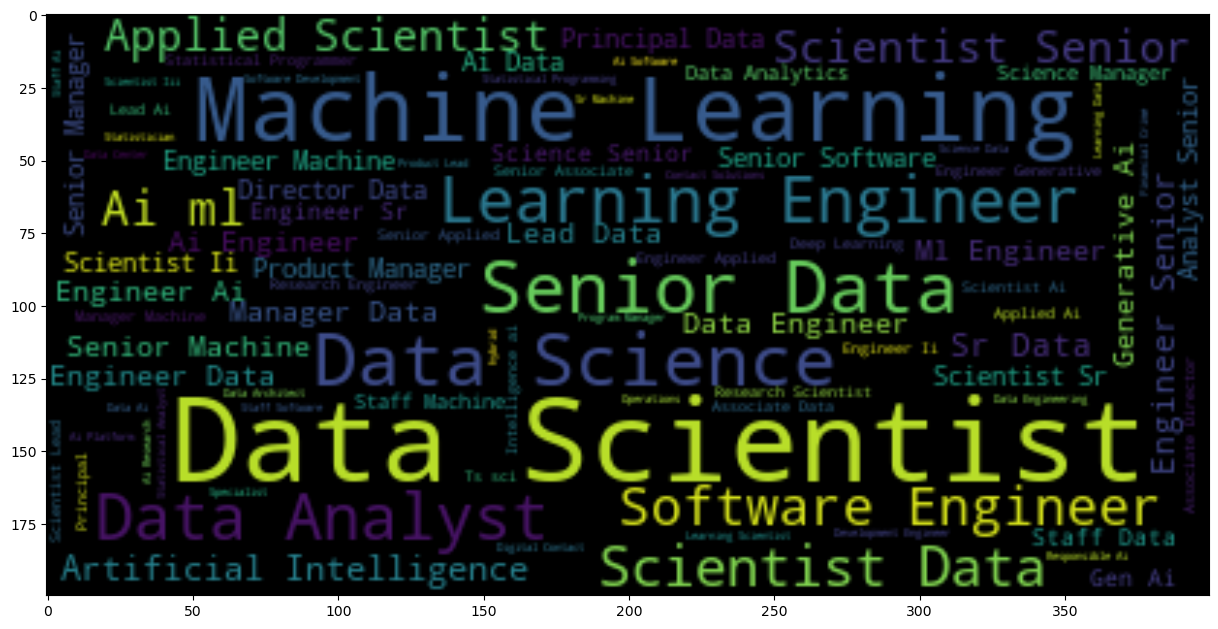

In [33]:
# visualize the most trending titles

plt.figure(figsize=(15,8))
titles = df['Title'].tolist()
titles_join = ["".join(title_list) for title_list in df['Title']]
all_titles = " ".join(titles_join)
wc = WordCloud().generate(all_titles)
plt.imshow(wc, interpolation='bilinear')

`Company`

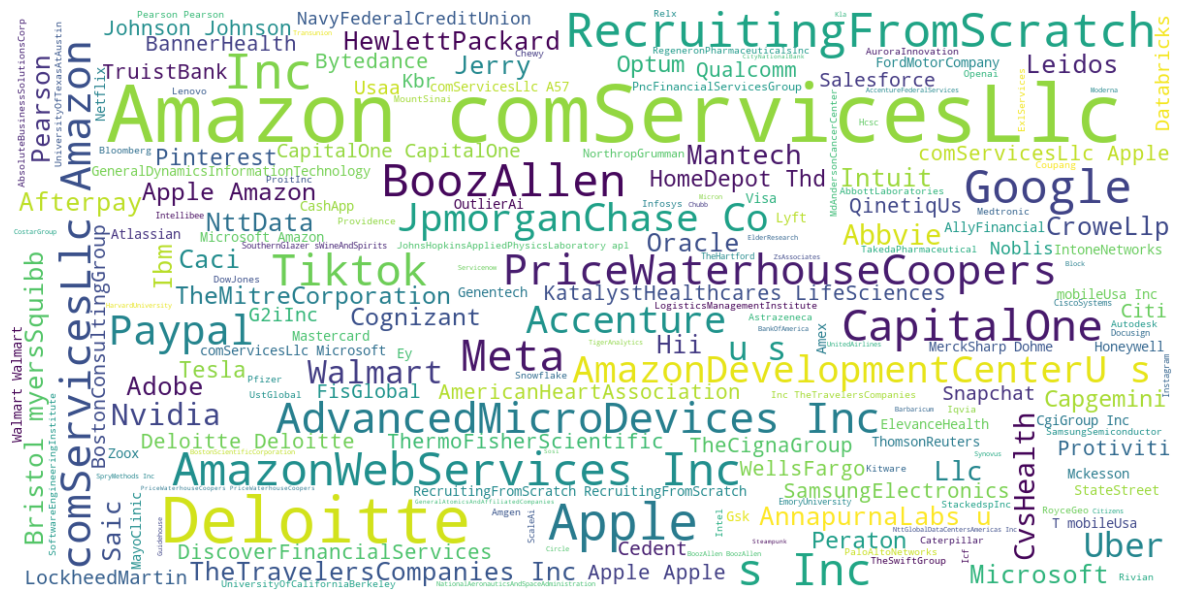

In [34]:
company_no_space = [company.replace(" ", "") for company in df['Company']] # Remove spaces in company names
all_companies = " ".join(company_no_space) # Join all company names into one string

# Generate word cloud
plt.figure(figsize=(15,8))
wc = WordCloud(width=1200, height=600, background_color='white').generate(all_companies)

# Display
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


Extract `Skills` from `Description` column

In [35]:
# identify most common data science skills to search
skills = [
    'Data Science', 'Machine Learning', 'Deep Learning', 'AI', 'Artificial Intelligence',
    'Data Analysis', 'Data Visualization', 'Tableau', 'Power BI', 'SQL', 'NoSQL',
    'Big Data', 'Hadoop', 'Spark', 'ETL', 'Python', 'R', 'Java', 'C++', 'JavaScript',
    'HTML', 'CSS', 'AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes', 'CI/CD', 
    'Project Management', 'Agile', 'Scrum', 'Communication', 'Problem Solving', 'Critical Thinking'
]

# Create a new column that will store extracted skills
def extract_skills(description):
    description = str(description).lower()  # convert to lowercase for case-insensitive match
    found_skills = [skill for skill in skills if skill.lower() in description]
    return ','.join(found_skills)  # join as comma-separated string

df['Skill keywords'] = df['Description'].apply(extract_skills)

df[['Description', 'Skill keywords']].head()

,Description,Skill keywords
0,"Familiarity with advanced machine learning, da...","Data Science,Machine Learning,R"
1,Must have strong technical skills in areas suc...,"Data Visualization,SQL,Python,R"
2,Excellent interpersonal skills and ability to ...,R
3,"As a data scientist, you’re excited at the pro...",R
4,You are experienced using web analytics and Go...,R


In [36]:
# Define function to convert the skills column into list
def to_skill_list(x):
    if isinstance(x, list):
        return [skill for skill in x if skill]
    elif isinstance(x, str):
        return [skill.strip() for skill in x.split(',') if skill.strip()]
    else:
        return []

# Apply to the column
df['Skill keywords'] = df['Skill keywords'].apply(to_skill_list)

# Flatten the list of lists
all_skills = [skill for skills_list in df['Skill keywords'] for skill in skills_list]

# Count occurrences
skill_counts = Counter(all_skills)

# Convert to DataFrame
skill_counts_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Number_of_Postings'])
skill_counts_df = skill_counts_df.sort_values(by='Number_of_Postings', ascending=False).reset_index(drop=True)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(skill_counts_df)

,Skill,Number_of_Postings
0,R,22744
1,Machine Learning,5570
2,AI,4900
3,Data Science,1820
4,Deep Learning,1144
5,Data Analysis,694
6,Data Visualization,684
7,Artificial Intelligence,664
8,Python,429
9,AWS,365


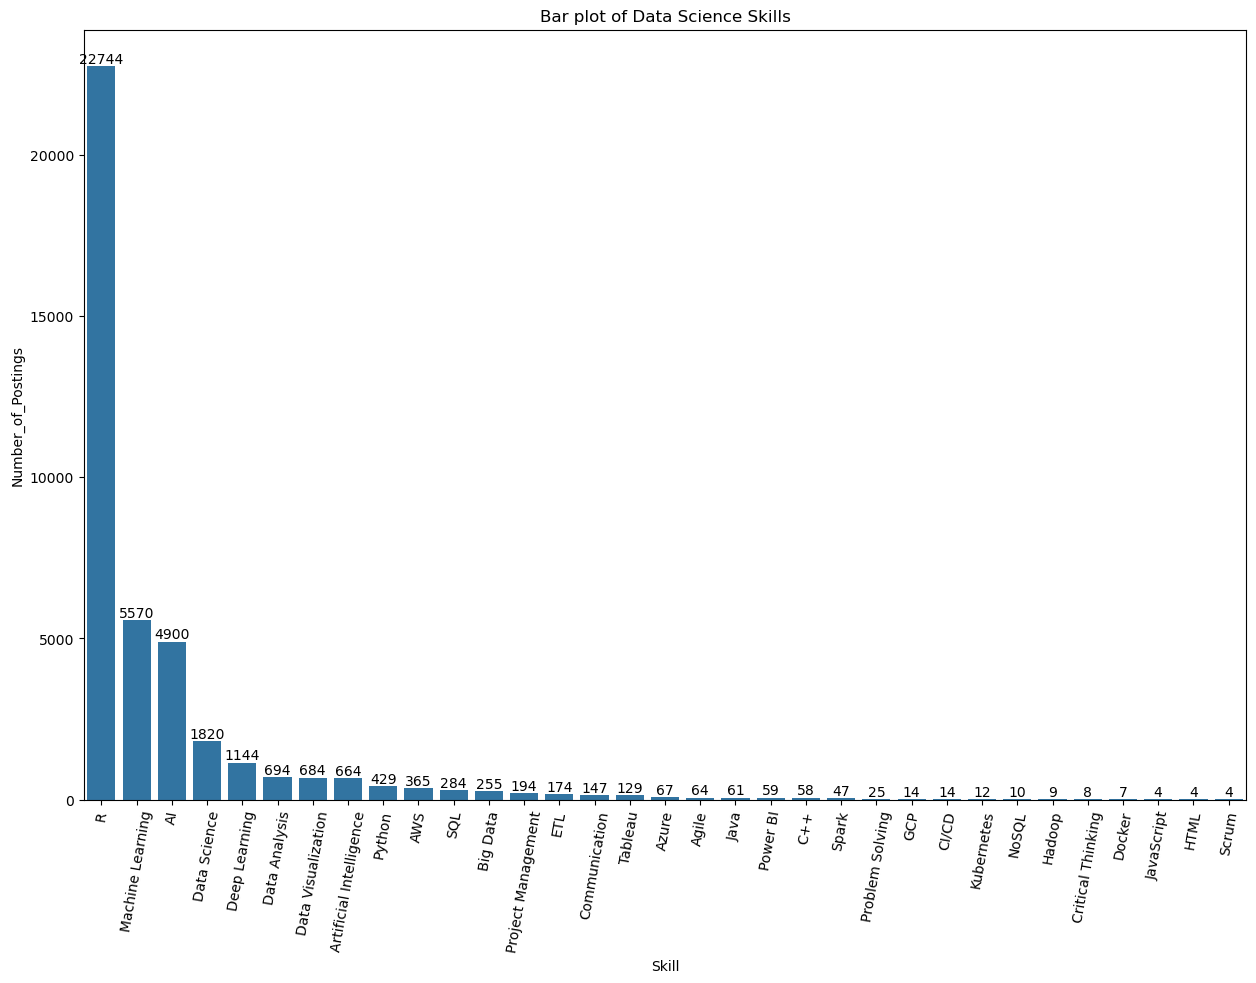

In [37]:
# plot the skill 
plt.figure(figsize=(15,10))

ax = sns.barplot(x=skill_counts_df['Skill'], y=skill_counts_df['Number_of_Postings'])
ax.bar_label(ax.containers[0])
plt.xticks(rotation=80)
plt.title('Bar plot of Data Science Skills')
plt.show()

- Among ~29,000 job postings, a total of 33 unique skills are mentioned. The field is heavily dominated by R (22,744 postings), followed by Machine Learning (5,570) and AI (4,900), highlighting the critical demand for core technical and analytical expertise in data science.

- Other frequently mentioned skills include Data Science, Deep Learning, Data Analysis, and Data Visualization, while programming languages like Python, SQL, and Java appear less often than expected.

- Project management and soft skills—Project Management, Communication, Agile, Critical Thinking, Scrum—are present but rare, suggesting that employers prioritize technical skills over general or managerial competencies.

- Niche tools such as Tableau, Power BI, Spark, AWS, Azure, GCP, Hadoop, Docker, Kubernetes, CI/CD, NoSQL, HTML, JavaScript appear at the lower end of the frequency spectrum, indicating occasional but specialized requirements.

`Average Salary`

Exclude observations with missing Average Salary data to ensure the analysis is based on complete information, allowing for a more accurate exploration of salary patterns and their correlations with other variables in the dataset.

In [38]:
df_sal = df.dropna(subset='Average Salary')

In [39]:
# display basic informations about the data
df_sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 1 to 29183
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             11371 non-null  datetime64[ns]
 1   Title            11371 non-null  object        
 2   Company          11371 non-null  object        
 3   State            11371 non-null  object        
 4   City             11371 non-null  object        
 5   Level            11371 non-null  object        
 6   Average Salary   11371 non-null  float64       
 7   Pay Type         11371 non-null  object        
 8   Employment Type  11371 non-null  object        
 9   Description      11371 non-null  object        
 10  Weekday          11371 non-null  object        
 11  Skill keywords   11371 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 1.1+ MB


Create a new `Annual Salary` column to convert all salary values to a consistent annual rate. This standardization helps reveal clearer salary patterns and supports building a reliable model later to predict missing salary values.

In [40]:
# define a function to convert the salary to annual rates
def to_annual_salary(row):
    salary = row['Average Salary']
    pay_type = row['Pay Type']
    
    if pd.isna(salary) or pd.isna(pay_type):
        return np.nan
    
    pay_type = pay_type.lower()  # make case-insensitive
    
    if pay_type == 'month':
        return salary * 12
    elif pay_type == 'week':
        return salary * 52
    elif pay_type == 'day':
        return salary * 365
    elif pay_type == 'hour':
        return salary * 40 * 52  # typical full-time work hours: 40 hours/week
    else:
        return salary  


Apply the function to `Average Salary` column and store the data in the new column `Annual Salary`


In [41]:
df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/4126299172.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)


Begin by examining the spread and distribution of the `Annual Salary` using box plots and histograms.

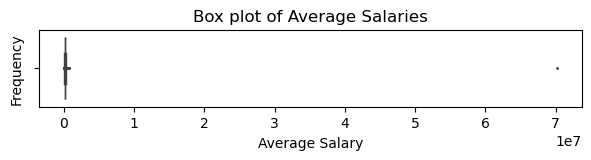

In [42]:
# create a box plot to detect outliers
salary = df_sal['Annual Salary']

plt.figure(figsize=(7,1))
sns.boxplot(x = salary,  fliersize=1)
plt.title('Box plot of Average Salaries')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

In [43]:
# check the outlier over 700k annual salary
df_sal[df_sal['Annual Salary'] >= 700000]

,Date,Title,Company,State,City,Level,Average Salary,Pay Type,Employment Type,Description,Weekday,Skill keywords,Annual Salary
13386,2024-07-15,Graduate Research Assistant/ Mathematical & St...,The University Of Texas Rio Grande Valley,Texas,Rio Grande Valley,Graduate,1350000.0,week,Casual,The Graduate Research Assistants will assist a...,Monday,[R],70200000.0


-> The data appear erroneous after the cleaning step, which multiplied the weekly salary rates by 1,000. Therefore, divide the Average Salary values by 1,000 to correct the scale. This adjustment ensures the salary figures are accurate and suitable for analyzing patterns and developing predictive models later.

In [44]:
# Update only the Average Salary column for this row
df_sal.loc[df_sal['Annual Salary'] >= 700000, 'Average Salary'] = df_sal.loc[df_sal['Annual Salary'] >= 700000, 'Average Salary'] / 1000

In [45]:
# reapply the annual salary convert function
df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/76165963.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Annual Salary'] = df_sal.apply(to_annual_salary, axis=1)


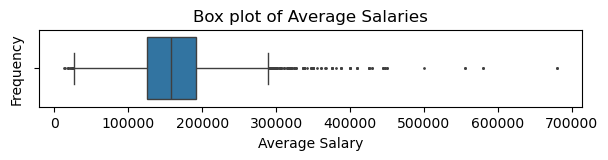

In [46]:
# create a new box plot for annual salary
salary = df_sal['Annual Salary']

plt.figure(figsize=(7,1))
sns.boxplot(x = salary,  fliersize=1)
plt.title('Box plot of Average Salaries')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

In [47]:
# detect and inspect outliers row

q1 = df_sal['Annual Salary'].quantile(0.25)
q3 = df_sal['Annual Salary'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

print(lower_limit, upper_limit)


26000.0 290000.0


In [48]:
outliers = df_sal[(df_sal['Annual Salary'] <= lower_limit) | (df_sal['Annual Salary'] >= upper_limit)]

print('Number of outliers', outliers.shape[0])
print('Percentage of outliers', outliers.shape[0] / df.shape[0] * 100)

outliers.head()

Number of outliers 163
Percentage of outliers 0.5588315962698848


,Date,Title,Company,State,City,Level,Average Salary,Pay Type,Employment Type,Description,Weekday,Skill keywords,Annual Salary
214,2024-06-23,"Data Scientist Lead, Tiktok Live - Trust & Safety",Tiktok,California,San Jose,Lead,298140.0,year,Full-time,Collaborate closely with cross-functional team...,Sunday,[R],298140.0
256,2024-06-23,"Director Data Science, Instagram Business",Instagram,California,Menlo Park,Mid-level,337500.0,year,Full-time,"Inspire, lead and grow a team of data scientis...",Sunday,[R],337500.0
306,2024-06-23,Director Data Science,Meta,California,Burlingame,Mid-level,337500.0,year,Full-time,Experience with both product analytics and bus...,Sunday,[R],337500.0
345,2024-06-23,Head Of Ai And Data Science,Verily,California,San Francisco,Mid-level,298000.0,year,Full-time,Strong track record of shipping products that ...,Sunday,"[Data Science, Machine Learning, AI, R]",298000.0
412,2024-06-23,"Data Science Director, Monetization Ranking Ai",Facebook App,California,Menlo Park,Mid-level,337500.0,year,Full-time,"Inspire, lead and grow a team of data scientis...",Sunday,[R],337500.0


After identifying the outliers and confirming they are not due to data errors, we will retain them for this analysis because:

* **Minimal impact:** Outliers constitute only 0.55% of the data, so they are unlikely to heavily skew overall statistics such as the mean or median.
* **Potentially valuable information:** Even a few outliers can provide meaningful insights, such as unusually high or low salaries or atypical company practices.
* **Analysis considerations:** For descriptive analysis and EDA, keeping outliers is useful. While certain models like linear regression may require sensitivity checks, tree-based models are generally robust to outliers.


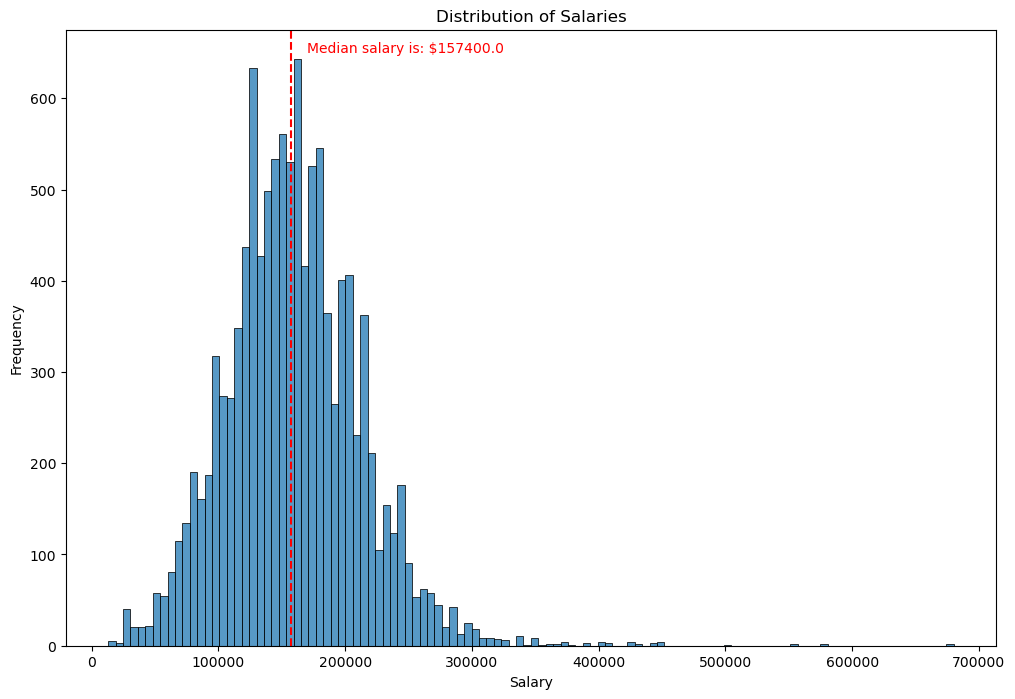

In [49]:
# create a histogram to for annual salary distribution
median = df_sal['Annual Salary'].median()
median_text = 'Median salary is: ' +'$'+ str(median) 

plt.figure(figsize=(12, 8))
sns.histplot(salary)
plt.axvline(median, color = 'red', linestyle='--')
plt.text(170000,650, median_text, color='red')
plt.title('Distribution of Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

The distribution plot has the right skew: mean > median (~ $159k > ~ $157k), meaning:

- Most people earn lower to mid-range salaries.
- A small number of people earn very high salaries, creating a long tail on the right side of the distribution.
- The mean (average) salary is pulled upward by these high earners and is usually higher than the median.

`Salary` by `Job level`

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/1848335034.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/1848335034.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)


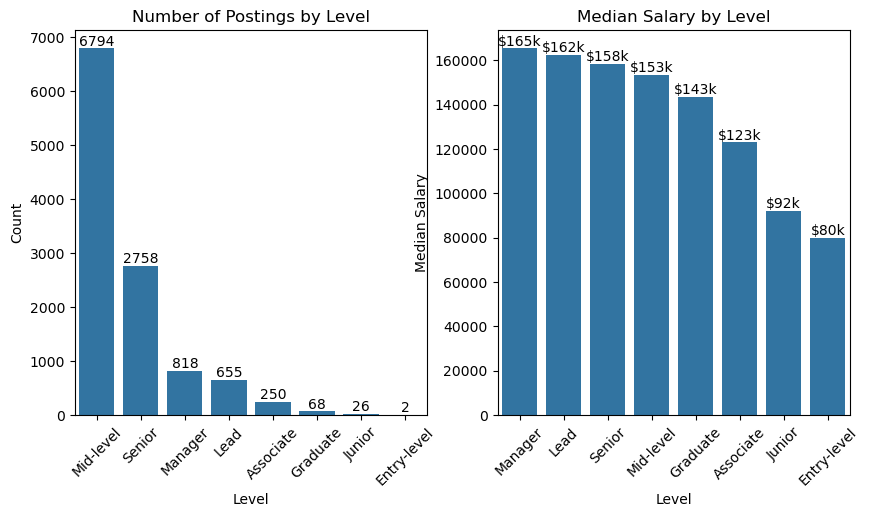

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# plot the job by level distribution
level_dist = df_sal.groupby('Level').size().sort_values(ascending = False)
sns.barplot(x=level_dist.index, y=level_dist.values, ax=ax[0])

ax[0].bar_label(ax[0].containers[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
ax[0].set_ylabel('Count')
ax[0].set_title('Number of Postings by Level')

# plot the median salary by level
level_sal = df_sal.groupby('Level')['Annual Salary'].median().sort_values(ascending = False).astype(int)
labels = [f"${int(salary/1000)}k" for salary in level_sal.values]

sns.barplot(x=level_sal.index, y = level_sal.values, ax = ax[1])
ax[1].bar_label(ax[1].containers[0], labels = labels)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45)
ax[1].set_ylabel('Median Salary')
ax[1].set_title('Median Salary by Level')
plt.show()

Create a `Salary category` column for more insights

In [51]:
df_sal['Level_category'] = df_sal['Level'].replace({
    'Associate': 'entry role',
    'Entry-level': 'entry role',
    'Junior': 'entry role',
    'Graduate': 'entry role',
    'Mid-level': 'mid level',
    'Senior': 'mid level',
    'Lead': 'high level',
    'Manager': 'high level'
})

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/1632280923.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sal['Level_category'] = df_sal['Level'].replace({


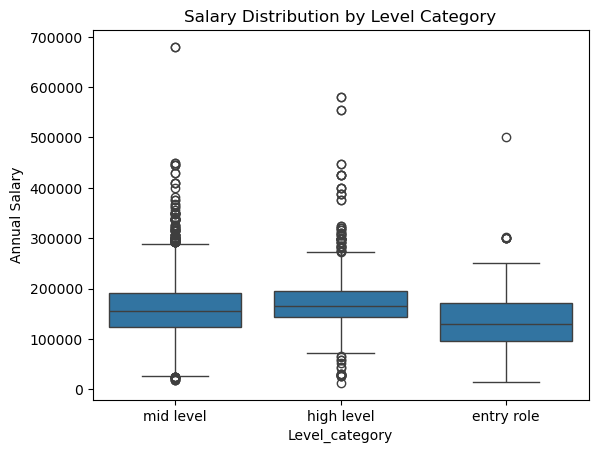

In [52]:
sns.boxplot(data=df_sal, x='Level_category', y='Annual Salary')
plt.title("Salary Distribution by Level Category")
plt.show()

/var/folders/5v/wc8gxzt56gx00tb3h88t55vm0000gn/T/ipykernel_98149/4090284650.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Level Category')


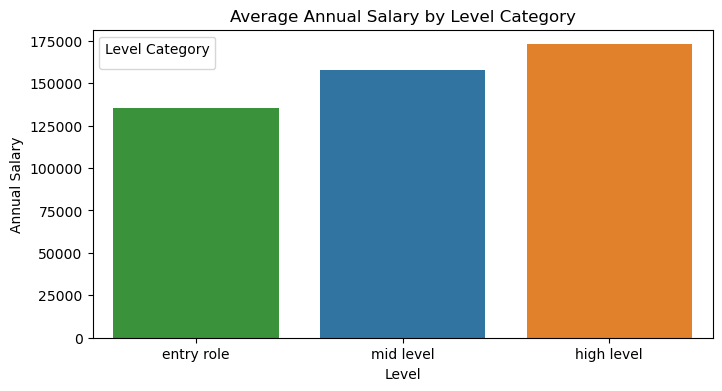

In [53]:
# Compute average salary by Level
level_order = df_sal.groupby('Level_category')['Annual Salary'].median().sort_values().index

plt.figure(figsize=(8,4))
ax = sns.barplot(
    data=df_sal,
    x='Level_category',
    y='Annual Salary',
    hue='Level_category',
    order=level_order, 
    ci=None
)

plt.title("Average Annual Salary by Level Category")
plt.ylabel("Annual Salary")
plt.xlabel("Level")
plt.legend(title='Level Category')
plt.show()


In [54]:
df_sal.groupby('Level_category')['Annual Salary'].median().sort_values()

Level_category
entry role    129600.0
mid level     155344.8
high level    164500.0
Name: Annual Salary, dtype: float64

In [55]:
df_sal['Level'].value_counts() / df_sal.shape[0]

Level
Mid-level      0.597485
Senior         0.242547
Manager        0.071937
Lead           0.057603
Associate      0.021986
Graduate       0.005980
Junior         0.002287
Entry-level    0.000176
Name: count, dtype: float64

* **Job postings by level:** Mid-level positions dominate the dataset, representing nearly **60%** of all postings. Senior roles follow with about **24%**, while Manager and Lead roles together make up roughly **13%**. Entry-level and Junior positions account for less than **1%** of the postings.
* **Median salary by level:** There is a strong positive correlation between job level and median salary. Managers receive the highest median salary at approximately **$165k**, followed closely by Leads (**$162k**), Seniors (**$158k**), and Mid-level roles (**$153k**). Graduate and Associate positions earn moderately, with median salaries of around **$143k** and **$123k** respectively, while Junior and Entry-level roles have the lowest median salaries, roughly **$92k** and **$80k**.
* **Salary benchmarks by category:** Grouping salaries by level category reveals expected median salaries of approximately **$129,600** for entry-level roles, **$155,345** for mid-level, and **$164,500** for high-level positions. These benchmarks can help identify whether a given salary is underpaid, fairly compensated, or above average for its respective level.


`Salary` by `Location`

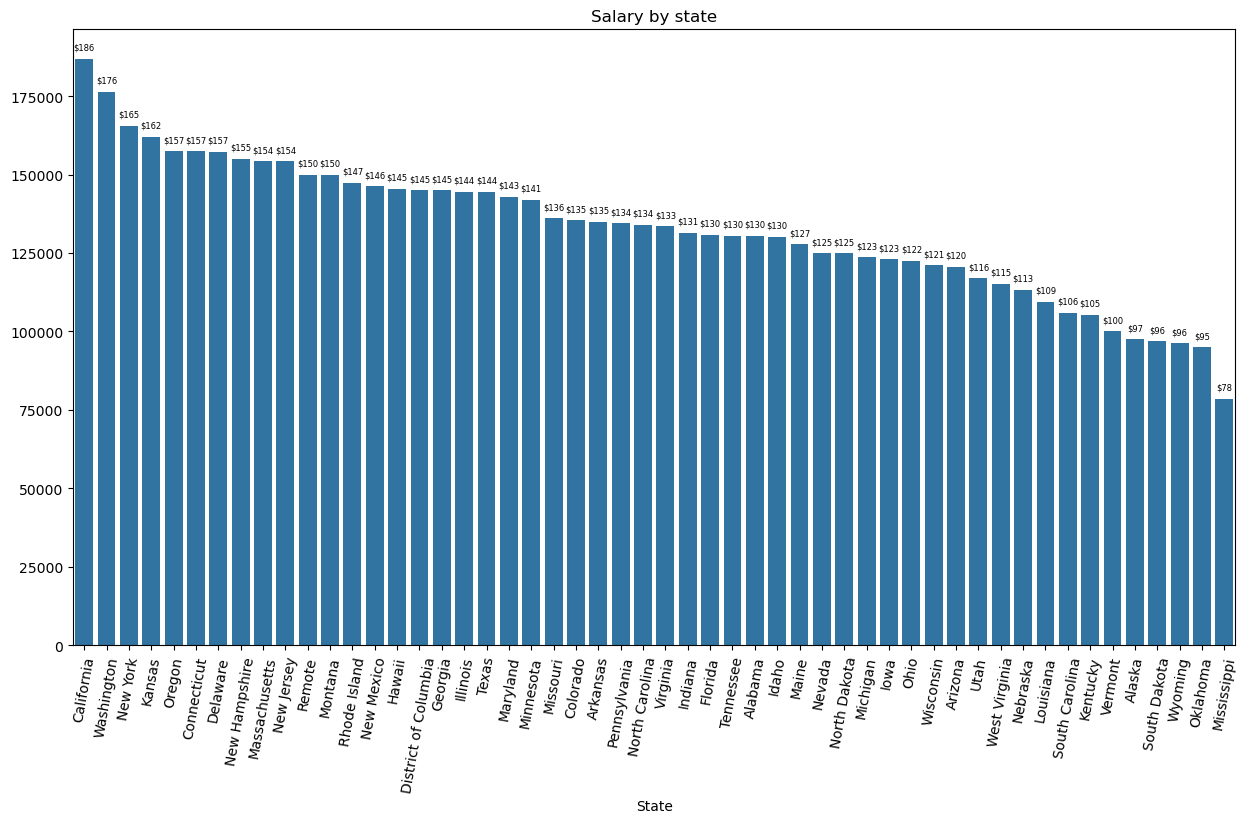

In [56]:
# plot the salary by state
state = df_sal.groupby('State')['Annual Salary'].median().sort_values(ascending=False).astype(int)
labels = [f"${int(salary/1000)}" for salary in state.values]

plt.figure(figsize=(15,8))
ax = sns.barplot(x= state.index, y = state.values)
plt.xticks(rotation = 80)
plt.bar_label(ax.containers[0], labels = labels, fontsize=6, padding=5)
plt.title('Salary by state')
plt.show()

- With a median salary of approximately $186K and the highest number of job postings, California demonstrates that major tech companies tend to offer higher compensation than other firms.

TOp 10 companies paid hgihest per level category

In [57]:
top_10_entry = df_sal.loc[df_sal['Level_category']=='entry role'].groupby('Company')['Annual Salary'].median().sort_values(ascending=False).head(10)
top_10_mid = df_sal.loc[df_sal['Level_category']=='mid level'].groupby('Company')['Annual Salary'].median().sort_values(ascending=False).head(10)
top_10_high = df_sal.loc[df_sal['Level_category']=='high level'].groupby('Company')['Annual Salary'].median().sort_values(ascending=False).head(10)

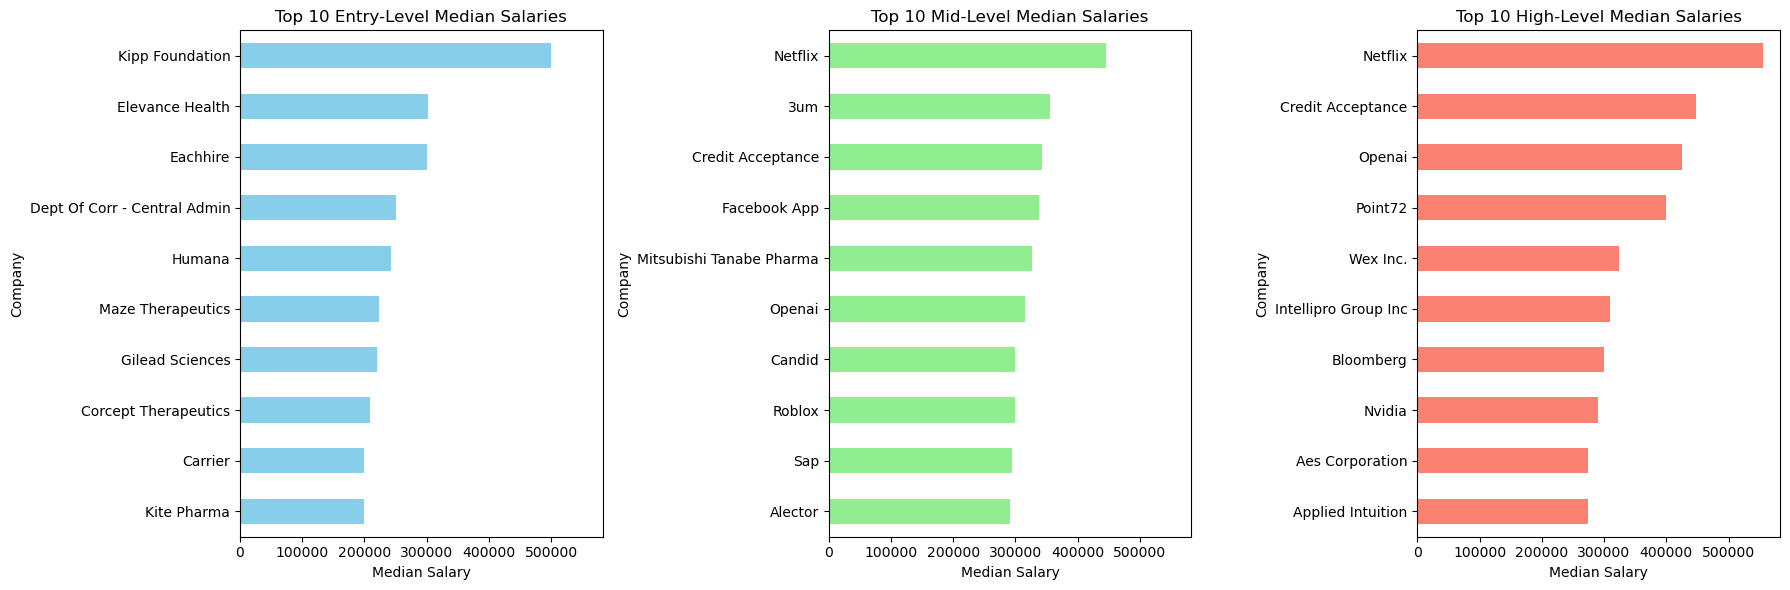

In [58]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharex=True)

top_10_entry.sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Entry-Level Median Salaries')
axes[0].set_xlabel('Median Salary')
axes[0].set_ylabel('Company')

top_10_mid.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Top 10 Mid-Level Median Salaries')
axes[1].set_xlabel('Median Salary')

top_10_high.sort_values(ascending=True).plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Top 10 High-Level Median Salaries')
axes[2].set_xlabel('Median Salary')

plt.tight_layout()
plt.show()


Correlation Heatmap of Annual Salary with Other Variables

In [59]:
df_sal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 1 to 29183
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             11371 non-null  datetime64[ns]
 1   Title            11371 non-null  object        
 2   Company          11371 non-null  object        
 3   State            11371 non-null  object        
 4   City             11371 non-null  object        
 5   Level            11371 non-null  object        
 6   Average Salary   11371 non-null  float64       
 7   Pay Type         11371 non-null  object        
 8   Employment Type  11371 non-null  object        
 9   Description      11371 non-null  object        
 10  Weekday          11371 non-null  object        
 11  Skill keywords   11371 non-null  object        
 12  Annual Salary    11371 non-null  float64       
 13  Level_category   11371 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(11

In [60]:
# encode the category variables into numberic

df_encoded = df_sal.copy()
categorical_cols = ['Title', 'Company', 'State', 'City', 'Level', 'Pay Type', 'Employment Type']

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

NameError: name 'LabelEncoder' is not defined

In [ ]:
numeric_df = df_encoded.select_dtypes(include=['int64', 'float64']).drop(columns=['Average Salary'])
numeric_df.corr(method='pearson')

,Title,Company,State,City,Level,Pay Type,Employment Type,Annual Salary
Title,1.000000,0.046583,-0.033608,0.037086,0.210233,0.004694,0.010899,0.078608
Company,0.046583,1.000000,-0.086196,-0.006395,-0.071597,-0.063753,-0.038454,-0.058764
State,-0.033608,-0.086196,1.000000,0.037997,-0.005338,-0.030185,-0.031050,-0.102746
City,0.037086,-0.006395,0.037997,1.000000,0.006834,0.029709,0.018538,0.113350
Level,0.210233,-0.071597,-0.005338,0.006834,1.000000,-0.022627,-0.023479,0.028185
Pay Type,0.004694,-0.063753,-0.030185,0.029709,-0.022627,1.000000,0.866675,0.261023
Employment Type,0.010899,-0.038454,-0.031050,0.018538,-0.023479,0.866675,1.000000,0.209499
Annual Salary,0.078608,-0.058764,-0.102746,0.113350,0.028185,0.261023,0.209499,1.000000


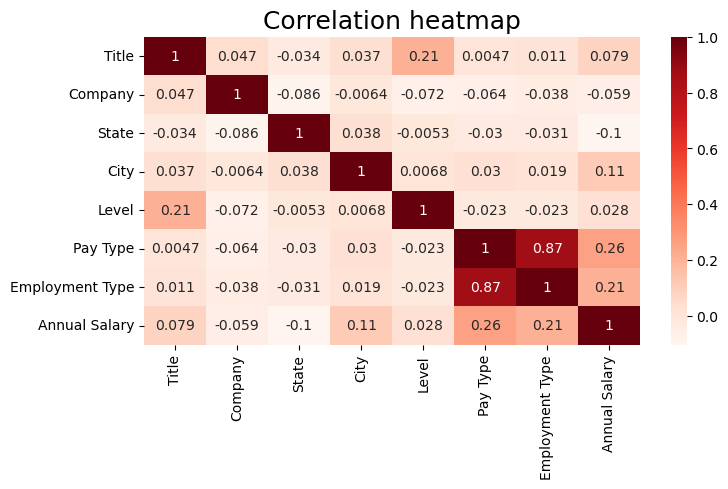

In [ ]:
# Create the heatmap
plt.figure(figsize=(8,4))
sns.heatmap(numeric_df.corr(method='pearson'), annot=True, cmap='Reds')
plt.title('Correlation heatmap', fontsize=18)
plt.show()

* **Annual Salary has very weak correlations** with most variables. The strongest relationships are with:

  * **Pay Type** (0.26)
  * **Employment Type** (0.21)
  * **City** (0.11)
    Other factors like Title, Company, State, and Level show almost no linear correlation with salary.

* **Level shows a weak positive correlation with Title** (0.21), indicating higher-level positions are somewhat associated with certain job titles.

* **Pay Type and Employment Type are strongly correlated** (0.87), which makes sense because certain pay types (e.g., hourly vs salary) tend to match specific employment types (full-time vs contract).

* Overall, **Annual Salary is mostly independent of company, state, and job title**, suggesting that other unobserved factors (like skills, experience, or negotiation) may influence salary more than these features.

## Step 3. Model Building
- Fit a model that predicts the outcome variable using two or more independent variables

To understand **which factors drive salary differences**, I trained a **CatBoost Regressor** using selected features below:

- Job Title + Level
- Company
- State
- City
- Employment Type
- Work Mode
- Skills extracted from descriptions

CatBoost is ideal because it natively handles categorical variables, automatically encodes them, and calculates feature importance based on its internal gradient-boosting trees.

Because CatBoost is sensitive with outliers, so checking the outcome variable (`Annual Salary`) and remove outliers before training the model helps to increase the accuracy score.

In [ ]:
#Display the summary statistic for Annual Salary column
df_sal['Annual Salary'].describe()

count     11208.000000
mean     156941.992238
std       47915.546731
min       26364.500000
25%      125000.000000
50%      156425.000000
75%      188812.500000
max      288400.000000
Name: Annual Salary, dtype: float64

In [ ]:
# because catboost is not handling well with outliers, so remove outliers for better model performance
df_sal =  df_sal[(df_sal['Annual Salary'] >= lower_limit) & (df_sal['Annual Salary'] <= upper_limit)]

NameError: name 'df_sal' is not defined

In [ ]:
# double check the Annual Salary column if the outliers is removed 
df_sal['Annual Salary'].describe()

count     11208.000000
mean     156941.992238
std       47915.546731
min       26364.500000
25%      125000.000000
50%      156425.000000
75%      188812.500000
max      288400.000000
Name: Annual Salary, dtype: float64

**Feature engineering**

- Combine Title and Level if Level is not in Title

In [ ]:
df_sal['Title_level'] = df_sal.apply(
    lambda row: row['Title'] if str(row['Level']).lower() in str(row['Title']).lower()
    else f"{row['Title']} {row['Level']}",
    axis=1
)

**Train the model**
- Use selected columns:`'Title', 'Level', 'Company', 'State', 'City', 'Employment Type', 'Skill keywords'` to predict the annual salaries


In [ ]:
# Make the Skill Keywords column become a list
df_sal['Skill keywords'] = df_sal['Skill keywords'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

# Define dependent and independent variables
y = df_sal['Annual Salary']
X = df_sal[['Title_level', 'Company', 'State', 'City', 'Employment Type', 'Skill keywords']]

# Train-validation set split
X_train, X_val, y_train, y_val = train_test_split( X, y, test_size=0.2, random_state=42)

# Build CatBoost Pools
categorical_cols = ['Title_level', 'Company', 'State', 'City', 'Employment Type']
text_features = ['Skill keywords']

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_cols,
    text_features=text_features
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=categorical_cols,
    text_features=text_features
)


# 5️⃣ Build and train model
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=4,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=200,
    task_type='CPU'
)

model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

# Predictions
y_train_pred = model.predict(train_pool)
y_pred = model.predict(val_pool)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Validation RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Validation R²: {r2:.2f}")

# 8️⃣ Display top 5 rows of prediction values
print("Predictions:", y_pred[:5])


0:	learn: 47191.0377919	test: 47183.6734291	best: 47183.6734291 (0)	total: 4.43ms	remaining: 6.65s
200:	learn: 34766.8397999	test: 32026.6451062	best: 32026.6451062 (200)	total: 333ms	remaining: 2.15s
400:	learn: 34039.5125769	test: 31620.3269229	best: 31620.3269229 (400)	total: 658ms	remaining: 1.8s
600:	learn: 33600.3450088	test: 31399.2854557	best: 31399.2854557 (600)	total: 983ms	remaining: 1.47s
800:	learn: 33266.5017643	test: 31293.6899073	best: 31292.1777339 (798)	total: 1.32s	remaining: 1.15s
1000:	learn: 32986.8018699	test: 31206.6231455	best: 31206.4859694 (996)	total: 1.64s	remaining: 819ms
1200:	learn: 32743.9904748	test: 31159.1412534	best: 31158.5930666 (1199)	total: 1.97s	remaining: 489ms
1400:	learn: 32496.5735393	test: 31103.7503608	best: 31103.7503608 (1400)	total: 2.29s	remaining: 162ms
1499:	learn: 32384.6575382	test: 31071.9177085	best: 31071.9177085 (1499)	total: 2.45s	remaining: 0us

bestTest = 31071.91771
bestIteration = 1499

Validation RMSE: 31071.92
MAE: 2356

## Step 4. Results and Evaluation
- Evaluate the model

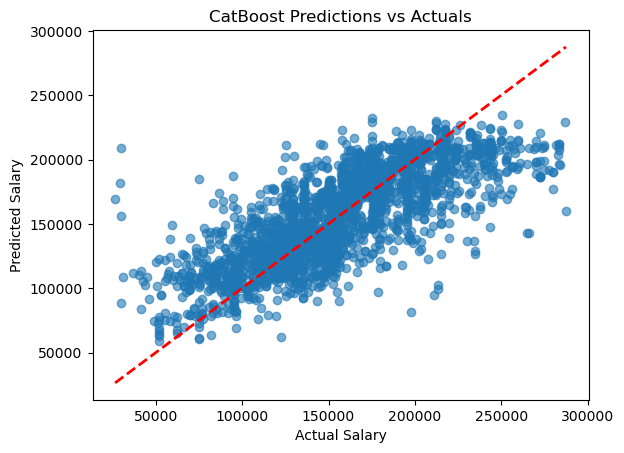

In [ ]:
# plot the predicted and actual annual salaries
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("CatBoost Predictions vs Actuals")
plt.show()


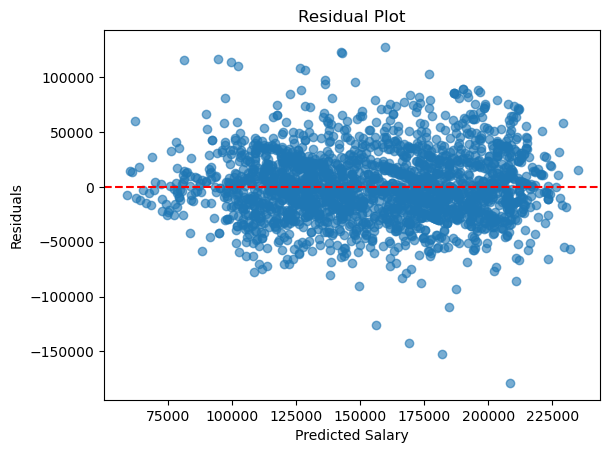

In [ ]:
# plot the residual vs predicted salary 
residuals = y_val - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


In [ ]:
# define a evaluation function to display the RMSE and R square score 
def evaluate(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.2f}, R²: {r2:.2f}")

evaluate(y_train, y_train_pred, "Train")
evaluate(y_val, y_pred, "Validation")

Train RMSE: 26229.36, R²: 0.70
Validation RMSE: 31071.92, R²: 0.58


**Feature Importance**

        Feature Id  Importances
0          Company    34.582228
1      Title_level    24.778788
2            State    13.725856
3             City    10.918493
4  Employment Type     8.996315
5   Skill keywords     6.998320


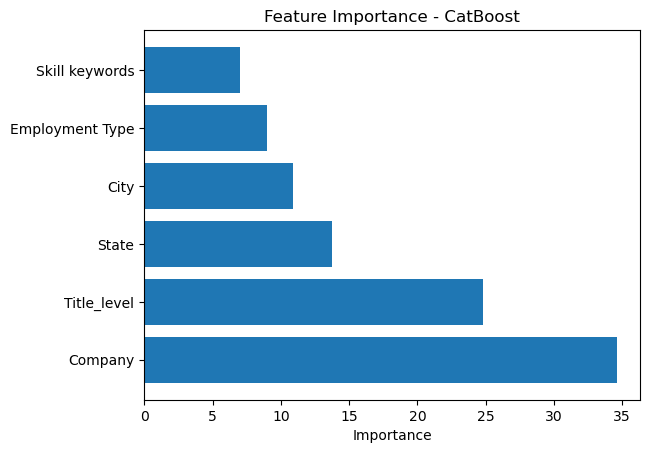

In [ ]:
# plot the feature importance
feature_importances = model.get_feature_importance(prettified=True)
print(feature_importances)

plt.barh(feature_importances['Feature Id'], feature_importances['Importances'])
plt.xlabel("Importance")
plt.title("Feature Importance - CatBoost")
plt.show()


- The model shows slight overfitting, as the R² on the validation set is about 12% lower than on the training set. 
- This means that the features we used — Company, Title + Level, State, City, and Skill Keywords — explain roughly 58% of the variance in annual salary.
- The remaining 42% of variance is likely due to factors not captured in the dataset, such as negotiation, individual responsibilities, experience, or other missing variables.
- The most important factor in predicting annual salaries is the Company, followed by the combination of job title and level. State and City also matter, while Employment Type and Skills have smaller effects. This matches intuition: employers and job roles drive most of the salary differences.

## Conclusions


### **1️⃣ Geography & Hiring Trends**

* **California dominates** data science hiring due to tech hubs like Silicon Valley.
* **Full-time positions (~97%)** are the standard.
* **Mid-level and senior roles** are most common, while low-level and manager roles are relatively rare.

### **2️⃣ Salary Insights**

* Most annual salaries are **below the median of $157K**, reflecting typical market ranges.
* Certain companies (e.g., Amazon) offer significantly higher pay, likely due to **seniority, special responsibilities, or company policies**.

### **3️⃣ Model Performance (CatBoost)**

* Training R² = 0.70, Validation R² = 0.58 → model explains **~55–60% of salary variance**.
* Slight overfitting exists but generalization is reasonable.
* **Predictions capture trends**, not exact salaries; individual values may vary due to negotiation, experience, or unobserved factors.

### **4️⃣ Feature Importance**

| Feature         | Importance | Interpretation                                         |
| --------------- | ---------- | ------------------------------------------------------ |
| Company         | 39%        | Employer has the largest impact on salary differences. |
| Title + Level   | 21%        | Role and seniority strongly affect pay.                |
| State           | 16%        | Regional differences influence salaries.               |
| City            | 12%        | Location within a state matters.                       |
| Employment Type | 8%         | Full-time vs contract/part-time affects pay.           |
| Skills          | 4%         | Specific skills matter, but less than other factors.   |

### **5️⃣ Recommendations**

* **Use predicted salaries** for budgeting, benchmarking, and market insights.
* **Add more explanatory features**: experience, education, certifications, and work mode to improve accuracy.
* Consider **salary ranges/bins** to better capture variation.
* Use **hyperparameter tuning** (GridSearchCV/Optuna) for optimal performance.
* Explore **stacked models** combining CatBoost, LightGBM, or XGBoost.
* Apply **K-Fold cross-validation** for robust performance estimates.

---

### **Summary Takeaway**

> The model captures general salary patterns: the **company and job level** are the strongest determinants, followed by **location and employment type**. About **40–45% of salary variance remains unexplained**, likely due to hidden factors such as negotiation, experience, or responsibilities. Improving model performance relies on **adding relevant features and better representing them**, rather than solely tuning parameters.
